# StudentLife — Behavior vs. Mood/Stress Correlation

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path(r"C:\Users\User\.cache\kagglehub\datasets\dartweichen\student-life\versions\1\dataset")
SENSING = ROOT / "sensing"
EMA_RESPONSE = ROOT / "EMA" / "response"

pd.set_option("display.max_columns", 50)
sns.set_theme(style="white")

In [2]:
# discover participant ids common to the sensing streams we'll use
def uids_in(folder, prefix):
    return {f.stem.replace(prefix, "") for f in folder.glob(f"{prefix}*.csv")}

activity_uids = uids_in(SENSING / "activity", "activity_")
conversation_uids = uids_in(SENSING / "conversation", "conversation_")
phonelock_uids = uids_in(SENSING / "phonelock", "phonelock_")
gps_uids = uids_in(SENSING / "gps", "gps_")

common_uids = sorted(activity_uids & conversation_uids & phonelock_uids & gps_uids)
print(f"{len(common_uids)} participants with all 4 sensing streams")
print(common_uids[:10], "...")

49 participants with all 4 sensing streams
['u00', 'u01', 'u02', 'u03', 'u04', 'u05', 'u07', 'u08', 'u09', 'u10'] ...


## EMA Mood / Stress response format

`Mood`: `happyornot`/`sadornot` are Yes(1)/No(2) gates, `happy`/`sad` are 1–4 intensity (only meaningful when the gate is Yes). `Stress.level` is 1–5: 1=a little stressed, 2=definitely stressed, 3=stressed out, 4=feeling good, 5=feeling great — not a clean monotonic "stress" axis, so we derive both a raw average and a `pct_stressed` (share of responses in {1,2,3}).

In [3]:
defn = json.loads((ROOT / "EMA" / "EMA_definition.json").read_text(encoding="utf-8", errors="ignore"))
defn_by_name = {d.get("name"): d for d in defn if isinstance(d, dict)}
for key in ["Mood", "Stress"]:
    print(f"--- {key} ---")
    for q in defn_by_name[key]["questions"]:
        print(f"  {q['question_id']:12s} {q['options']}")

--- Mood ---
  happyornot   (Yes) 1 2 (No)
  happy        [1]a little bit, [2]somewhat, [3]very much, [4]extremely, 
  sadornot     (Yes) 1 2 (No)
  sad          [1]a little bit, [2]somewhat, [3]very much, [4]extremely, 
  location     
--- Stress ---
  level        [1]A little stressed, [2]Definitely stressed, [3]Stressed out, [4]Feeling good, [5]Feeling great, 
  location     


## Daily behavioral features

One row per `(uid, date)`. `activity` samples are near-continuous, so it anchors which days exist; conversation / phonelock / gps / bluetooth / sms / call are left-joined on top and missing days filled with 0 (no event that day, not missing data).

In [4]:
def load_activity_daily(uid):
    df = pd.read_csv(SENSING / "activity" / f"activity_{uid}.csv", index_col=False)
    df.columns = df.columns.str.strip()
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df["date"] = pd.to_datetime(df["timestamp"], unit="s").dt.date
    df["is_active"] = df["activity inference"].isin(["1", "2", 1, 2]).astype(int)
    daily = df.groupby("date").agg(
        activity_samples=("activity inference", "size"),
        active_ratio=("is_active", "mean"),
    ).reset_index()
    daily["uid"] = uid
    return daily


def load_conversation_daily(uid):
    df = pd.read_csv(SENSING / "conversation" / f"conversation_{uid}.csv", index_col=False)
    df.columns = df.columns.str.strip()
    df["start_timestamp"] = pd.to_numeric(df["start_timestamp"], errors="coerce")
    df["end_timestamp"] = pd.to_numeric(df["end_timestamp"], errors="coerce")
    df = df.dropna(subset=["start_timestamp", "end_timestamp"])
    df["duration_min"] = (df["end_timestamp"] - df["start_timestamp"]) / 60
    df["date"] = pd.to_datetime(df["start_timestamp"], unit="s").dt.date
    daily = df.groupby("date").agg(
        conversation_minutes=("duration_min", "sum"),
        conversation_count=("duration_min", "size"),
    ).reset_index()
    daily["uid"] = uid
    return daily


def load_phonelock_daily(uid):
    df = pd.read_csv(SENSING / "phonelock" / f"phonelock_{uid}.csv", index_col=False)
    df.columns = df.columns.str.strip()
    df["start"] = pd.to_numeric(df["start"], errors="coerce")
    df["end"] = pd.to_numeric(df["end"], errors="coerce")
    df = df.dropna(subset=["start", "end"])
    df["duration_min"] = (df["end"] - df["start"]) / 60
    df["date"] = pd.to_datetime(df["start"], unit="s").dt.date
    daily = df.groupby("date").agg(
        phonelock_minutes=("duration_min", "sum"),
        phonelock_count=("duration_min", "size"),
    ).reset_index()
    daily["uid"] = uid
    return daily


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def load_gps_daily(uid):
    # NOTE: gps_*.csv has a trailing comma (extra unnamed 11th field) that makes pandas
    # silently use the first column as an index and shift every named column by one --
    # index_col=False disables that inference.
    df = pd.read_csv(SENSING / "gps" / f"gps_{uid}.csv", index_col=False)
    df.columns = df.columns.str.strip()
    df["time"] = pd.to_numeric(df["time"], errors="coerce")
    df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
    df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
    df = df.dropna(subset=["time", "latitude", "longitude"]).sort_values("time")
    df["date"] = pd.to_datetime(df["time"], unit="s").dt.date
    df["prev_lat"] = df.groupby("date")["latitude"].shift()
    df["prev_lon"] = df.groupby("date")["longitude"].shift()
    mask = df["prev_lat"].notna()
    df.loc[mask, "seg_km"] = haversine_km(
        df.loc[mask, "prev_lat"], df.loc[mask, "prev_lon"], df.loc[mask, "latitude"], df.loc[mask, "longitude"]
    )
    daily = df.groupby("date").agg(
        gps_distance_km=("seg_km", "sum"),
        gps_points=("latitude", "size"),
    ).reset_index()
    daily["uid"] = uid
    return daily


def load_bluetooth_daily(uid):
    # bt_u{id}.csv: time, MAC, class_id, level (RSSI). Each row is one nearby-device
    # detection from a periodic scan. unique_devices/day is the social-proximity /
    # interaction-density proxy used in the original StudentLife papers; scans/day is
    # just detection volume (repeat sightings of the same device across scan windows).
    f = SENSING / "bluetooth" / f"bt_{uid}.csv"
    empty = pd.DataFrame(columns=["date", "uid", "bluetooth_scans", "bluetooth_unique_devices"])
    if not f.exists():
        return empty
    df = pd.read_csv(f, index_col=False)
    df.columns = df.columns.str.strip()
    df["time"] = pd.to_numeric(df["time"], errors="coerce")
    df = df.dropna(subset=["time", "MAC"])
    if df.empty:
        return empty
    df["date"] = pd.to_datetime(df["time"], unit="s").dt.date
    daily = df.groupby("date").agg(
        bluetooth_scans=("MAC", "size"),
        bluetooth_unique_devices=("MAC", "nunique"),
    ).reset_index()
    daily["uid"] = uid
    return daily


def load_sms_daily(uid):
    f = ROOT / "sms" / f"sms_{uid}.csv"
    empty = pd.DataFrame(columns=["date", "uid", "sms_count"])
    if not f.exists():
        return empty
    df = pd.read_csv(f, encoding="utf-8-sig", index_col=False)
    df.columns = df.columns.str.strip()
    if "MESSAGES_date" not in df.columns or "timestamp" not in df.columns:
        return empty
    df = df.dropna(subset=["MESSAGES_date"])
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])
    if df.empty:
        return empty
    df["date"] = pd.to_datetime(df["timestamp"], unit="s").dt.date
    daily = df.groupby("date").size().rename("sms_count").reset_index()
    daily["uid"] = uid
    return daily


def load_call_daily(uid):
    f = ROOT / "call_log" / f"call_log_{uid}.csv"
    empty = pd.DataFrame(columns=["date", "uid", "call_count", "call_duration_min"])
    if not f.exists():
        return empty
    df = pd.read_csv(f, encoding="utf-8-sig", index_col=False)
    df.columns = df.columns.str.strip()
    if "CALLS_duration" not in df.columns or "timestamp" not in df.columns:
        return empty
    df["CALLS_duration"] = pd.to_numeric(df["CALLS_duration"], errors="coerce")
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["CALLS_duration", "timestamp"])
    if df.empty:
        return empty
    df["date"] = pd.to_datetime(df["timestamp"], unit="s").dt.date
    daily = df.groupby("date").agg(
        call_count=("CALLS_duration", "size"),
        call_duration_min=("CALLS_duration", lambda s: s.sum() / 60),
    ).reset_index()
    daily["uid"] = uid
    return daily

## Daily EMA mood / stress aggregation

In [5]:
def load_mood_daily(uid):
    f = EMA_RESPONSE / "Mood" / f"Mood_{uid}.json"
    if not f.exists():
        return pd.DataFrame(columns=["date", "uid", "mood_score", "mood_responses"])
    data = json.loads(f.read_text(encoding="utf-8", errors="ignore"))
    rows = []
    for r in data:
        rt = r.get("resp_time")
        if rt is None:
            continue
        happy = int(r["happy"]) if r.get("happyornot") == "1" and str(r.get("happy", "")).isdigit() else 0
        sad = int(r["sad"]) if r.get("sadornot") == "1" and str(r.get("sad", "")).isdigit() else 0
        rows.append({"date": pd.to_datetime(int(rt), unit="s").date(), "mood_score": happy - sad})
    if not rows:
        return pd.DataFrame(columns=["date", "uid", "mood_score", "mood_responses"])
    df = pd.DataFrame(rows)
    daily = df.groupby("date").agg(
        mood_score=("mood_score", "mean"),
        mood_responses=("mood_score", "size"),
    ).reset_index()
    daily["uid"] = uid
    return daily


def load_stress_daily(uid):
    f = EMA_RESPONSE / "Stress" / f"Stress_{uid}.json"
    if not f.exists():
        return pd.DataFrame(columns=["date", "uid", "stress_level", "pct_stressed", "stress_responses"])
    data = json.loads(f.read_text(encoding="utf-8", errors="ignore"))
    rows = []
    for r in data:
        lvl, rt = r.get("level"), r.get("resp_time")
        if lvl is None or rt is None or not str(lvl).isdigit():
            continue
        rows.append({"date": pd.to_datetime(int(rt), unit="s").date(), "level": int(lvl)})
    if not rows:
        return pd.DataFrame(columns=["date", "uid", "stress_level", "pct_stressed", "stress_responses"])
    df = pd.DataFrame(rows)
    daily = df.groupby("date").agg(
        stress_level=("level", "mean"),
        pct_stressed=("level", lambda s: (s <= 3).mean()),
        stress_responses=("level", "size"),
    ).reset_index()
    daily["uid"] = uid
    return daily

## Build the daily table across all participants

In [6]:
behavior_frames = []
mood_frames = []
stress_frames = []
skipped = []

for uid in common_uids:
    try:
        act = load_activity_daily(uid)
    except Exception as e:
        skipped.append((uid, "activity", str(e)))
        continue  # no activity backbone -> can't anchor this user's days

    def safe(func, label):
        try:
            return func(uid)
        except Exception as e:
            skipped.append((uid, label, str(e)))
            return pd.DataFrame(columns=["date", "uid"])

    conv = safe(load_conversation_daily, "conversation")
    lock = safe(load_phonelock_daily, "phonelock")
    gps = safe(load_gps_daily, "gps")
    bt = safe(load_bluetooth_daily, "bluetooth")
    sms = safe(load_sms_daily, "sms")
    call = safe(load_call_daily, "call")

    day = act
    for extra in (conv, lock, gps, bt, sms, call):
        day = day.merge(extra, on=["uid", "date"], how="left")
    num_cols = day.columns.difference(["uid", "date"])
    day[num_cols] = day[num_cols].fillna(0)
    behavior_frames.append(day)

    mood_frames.append(safe(load_mood_daily, "mood"))
    stress_frames.append(safe(load_stress_daily, "stress"))

behavior = pd.concat(behavior_frames, ignore_index=True)
mood = pd.concat(mood_frames, ignore_index=True)
stress = pd.concat(stress_frames, ignore_index=True)

ema = mood.merge(stress, on=["uid", "date"], how="outer")
daily_df = behavior.merge(ema, on=["uid", "date"], how="inner")

print("behavior rows:", len(behavior), "| ema rows:", len(ema), "| merged daily rows:", len(daily_df))
if skipped:
    print(f"\n{len(skipped)} source(s) skipped due to malformed files:")
    for uid, label, err in skipped:
        print(f"  {uid} / {label}: {err}")
daily_df.head()

behavior rows: 2883 | ema rows: 1298 | merged daily rows: 1269


,date,activity_samples,active_ratio,uid,conversation_minutes,conversation_count,phonelock_minutes,phonelock_count,gps_distance_km,gps_points,bluetooth_scans,bluetooth_unique_devices,sms_count,call_count,call_duration_min,mood_score,mood_responses,stress_level,pct_stressed,stress_responses
0,2013-03-27,6640,0.156627,u00,382.850000,21.0,590.700000,5.0,65.395914,58.0,169.0,39.0,0.0,7.0,27.75,NaN,NaN,1.0,1.0,1
1,2013-03-28,7634,0.072701,u00,348.366667,21.0,81.400000,1.0,164.698301,68.0,150.0,37.0,0.0,8.0,1.716667,NaN,NaN,2.666667,0.666667,6
2,2013-03-29,7972,0.127446,u00,479.116667,32.0,674.716667,6.0,110.809545,65.0,196.0,56.0,0.0,3.0,5.8,NaN,NaN,2.5,0.5,4
3,2013-03-30,4679,0.082496,u00,528.033333,32.0,443.200000,4.0,19.969245,41.0,24.0,6.0,0.0,2.0,0.0,NaN,NaN,4.0,0.0,1
4,2013-03-31,8004,0.167041,u00,597.683333,22.0,1226.650000,6.0,83.016846,72.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,4.5,0.0,2


In [7]:
# diagnostic: gps_distance_km / gps_points showed up as zero-variance (NaN correlation) -- why?
raw_bad = pd.read_csv(SENSING / "gps" / "gps_u00.csv")
raw_bad.columns = raw_bad.columns.str.strip()
print("without index_col=False -- columns shift because of a trailing comma in the source file:")
print(raw_bad[["time", "latitude", "longitude"]].head(2))

raw_fixed = pd.read_csv(SENSING / "gps" / "gps_u00.csv", index_col=False)
raw_fixed.columns = raw_fixed.columns.str.strip()
print("\nwith index_col=False -- correctly aligned:")
print(raw_fixed[["time", "latitude", "longitude"]].head(2))

without index_col=False -- columns shift because of a trailing comma in the source file:
               time   latitude   longitude
1364356963  network -72.329240    0.000000
1364358144      gps -72.329018  250.899994

with index_col=False -- correctly aligned:
         time   latitude  longitude
0  1364356963  43.759135 -72.329240
1  1364358144  43.759503 -72.329018


## Correlation matrix

Pearson correlation across every engineered numeric column (behavior + mood/stress) at the daily-per-student grain. Diverging blue↔red colormap, gray at zero.

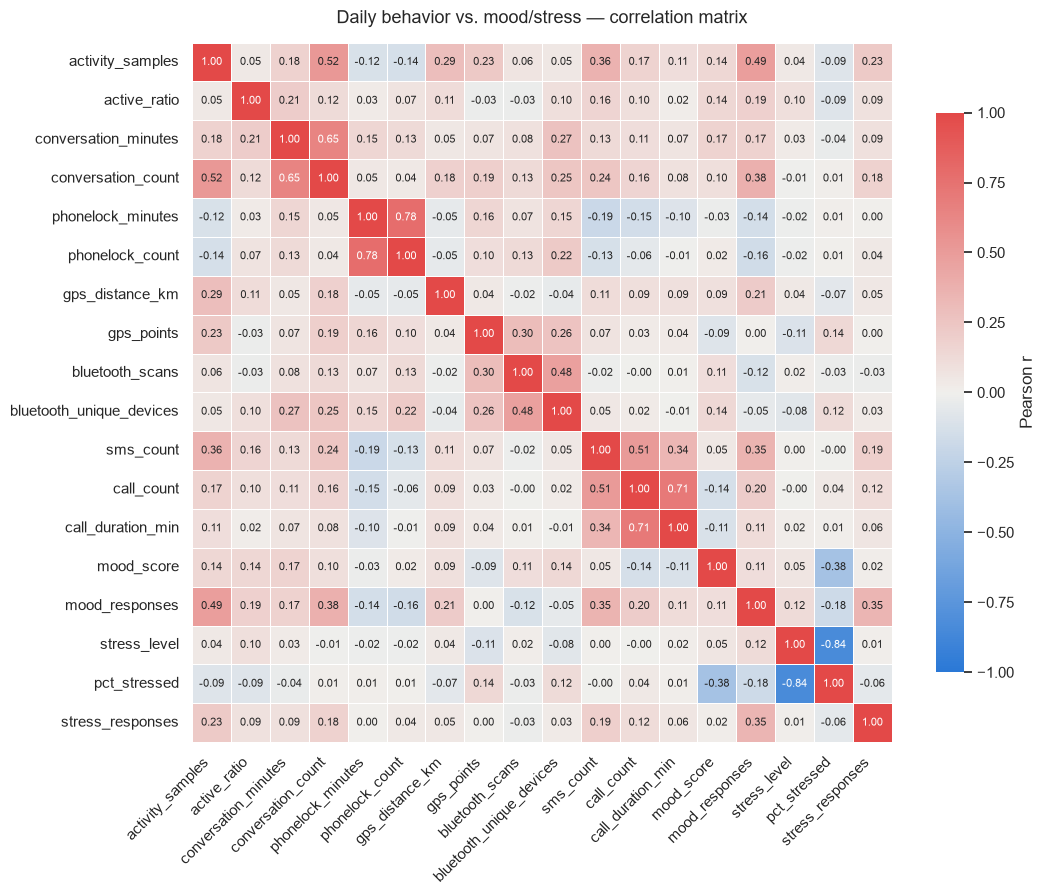

In [8]:
from matplotlib.colors import LinearSegmentedColormap

feature_cols = [c for c in daily_df.columns if c not in ("uid", "date")]
for c in feature_cols:
    daily_df[c] = pd.to_numeric(daily_df[c], errors="coerce")

corr = daily_df[feature_cols].corr(numeric_only=True)

diverging = LinearSegmentedColormap.from_list(
    "blue_red", ["#2a78d6", "#f0efec", "#e34948"]
)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, ax=ax, cmap=diverging, vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    linewidths=0.5, linecolor="white", square=True,
    cbar_kws={"label": "Pearson r", "shrink": 0.8},
)
ax.set_title("Daily behavior vs. mood/stress — correlation matrix", fontsize=13, pad=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Zoom: what correlates with mood_score / stress_level

In [9]:
targets = ["mood_score", "stress_level", "pct_stressed"]
behavior_only = [c for c in feature_cols if c not in targets and "responses" not in c]
print(corr.loc[behavior_only, targets].sort_values("mood_score", ascending=False))

                          mood_score  stress_level  pct_stressed
conversation_minutes        0.170630      0.027539     -0.038768
active_ratio                0.142664      0.099303     -0.086571
activity_samples            0.142191      0.041806     -0.086963
bluetooth_unique_devices    0.136829     -0.078051      0.117887
bluetooth_scans             0.105487      0.018433     -0.029551
conversation_count          0.098726     -0.011903      0.010731
gps_distance_km             0.090497      0.040878     -0.069334
sms_count                   0.054324      0.003357     -0.001516
phonelock_count             0.023641     -0.020697      0.007420
phonelock_minutes          -0.030116     -0.018989      0.012354
gps_points                 -0.089534     -0.105496      0.135239
call_duration_min          -0.111283      0.020256      0.011136
call_count                 -0.137161     -0.000788      0.039138


In [10]:
# corr() uses pairwise-complete observations, not all 1269 rows for every cell --
# behavior columns are always populated (filled with 0), but mood_score/stress_level
# are NaN on days where that specific EMA prompt wasn't answered (outer-joined).
print("non-null count per column (out of", len(daily_df), "total rows):")
print(daily_df[feature_cols].notna().sum().sort_values(ascending=False))

print("\npairwise N used by corr() for the mood/stress columns vs a behavior column:")
mask = daily_df[feature_cols].notna().astype(int)
pairwise_n = mask.T.dot(mask)
print(pairwise_n.loc[["mood_score", "stress_level", "pct_stressed"], ["activity_samples", "mood_score", "stress_level"]])

non-null count per column (out of 1269 total rows):
activity_samples            1269
active_ratio                1269
conversation_minutes        1269
conversation_count          1269
phonelock_minutes           1269
phonelock_count             1269
gps_distance_km             1269
gps_points                  1269
bluetooth_scans             1269
bluetooth_unique_devices    1269
sms_count                   1269
call_count                  1269
call_duration_min           1269
stress_level                1216
stress_responses            1216
pct_stressed                1216
mood_score                   200
mood_responses               200
dtype: int64

pairwise N used by corr() for the mood/stress columns vs a behavior column:
              activity_samples  mood_score  stress_level
mood_score                 200         200           147
stress_level              1216         147          1216
pct_stressed              1216         147          1216


## Partial correlation, controlling for Bluetooth social density

`bluetooth_unique_devices` shares real variance with `conversation_minutes` (r = 0.27) and `conversation_count` (r = 0.25) — both plausibly pick up "people nearby," not just "actively talking." To check whether the raw behavior→mood/stress correlations are riding on that shared social-context signal, this partials `bluetooth_unique_devices` out of every other behavior feature's correlation with `mood_score` / `stress_level` / `pct_stressed`:

r(x, y · z) = [r(x,y) − r(x,z)·r(y,z)] / sqrt[(1 − r(x,z)²)(1 − r(y,z)²)]

Each row's `r_raw` / `r_partial` pair uses the same listwise-complete subset (so the comparison is apples-to-apples, unlike the pairwise-complete matrix above).

In [11]:
def partial_corr(df, x, y, z):
    sub = df[[x, y, z]].dropna()
    n = len(sub)
    if n < 4:
        return np.nan, n
    rxy = sub[x].corr(sub[y])
    rxz = sub[x].corr(sub[z])
    ryz = sub[y].corr(sub[z])
    denom = np.sqrt((1 - rxz**2) * (1 - ryz**2))
    r_partial = (rxy - rxz * ryz) / denom if denom > 0 else np.nan
    return r_partial, n


control = "bluetooth_unique_devices"
rows = []
for target in ["mood_score", "stress_level", "pct_stressed"]:
    for feat in behavior_only:
        if feat == control:
            continue
        r_partial, n = partial_corr(daily_df, feat, target, control)
        rows.append({
            "target": target,
            "feature": feat,
            "r_raw": corr.loc[feat, target],
            "r_partial_control_bt": r_partial,
            "n": n,
        })

partial_df = pd.DataFrame(rows)
partial_df["shrinkage"] = partial_df["r_raw"] - partial_df["r_partial_control_bt"]
pd.set_option("display.width", 120)
print(partial_df.sort_values(["target", "r_raw"], ascending=[True, False]).to_string(index=False))

      target              feature     r_raw  r_partial_control_bt    n  shrinkage
  mood_score conversation_minutes  0.170630              0.133007  200   0.037622
  mood_score         active_ratio  0.142664              0.148341  200  -0.005677
  mood_score     activity_samples  0.142191              0.145864  200  -0.003673
  mood_score      bluetooth_scans  0.105487              0.018481  200   0.087006
  mood_score   conversation_count  0.098726              0.074637  200   0.024089
  mood_score      gps_distance_km  0.090497              0.103759  200  -0.013262
  mood_score            sms_count  0.054324              0.067138  200  -0.012813
  mood_score      phonelock_count  0.023641             -0.041556  200   0.065197
  mood_score    phonelock_minutes -0.030116             -0.071888  200   0.041772
  mood_score           gps_points -0.089534             -0.122747  200   0.033213
  mood_score    call_duration_min -0.111283             -0.112397  200   0.001114
  mood_score    